# TELCO CUSTOMER CHURN
# Customer risk segmentation and retention strategy

## Objective

This notebook translates the final churn model outputs into an actionable
retention framework.

The analysis uses customer-level churn probabilities generated by the
final Logistic Regression model to:

1. segment customers by churn risk;
2. identify common characteristics of higher-risk customers;
3. prioritize customers for retention outreach;
4. support the development of targeted retention strategies;
5. estimate the potential business impact of retention interventions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
overview_data = pd.read_csv("../../1_data/2_processed/telco_churn_clean.csv")

In [3]:
risk_results = pd.read_csv(
    "../../1_data/2_processed/final_churn_predictions.csv"
)

In [4]:
risk_results.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,actual_churn,churn_probabaility,predicted_churn
0,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.047876,0
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.682909,1
2,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.050820,0
3,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.420815,1
4,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.022827,0


In [5]:
risk_results.shape

(1409, 23)

In [6]:
risk_results.columns.tolist()

['customer_id',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'actual_churn',
 'churn_probabaility',
 'predicted_churn']

In [7]:
risk_results.isna().sum()

customer_id           0
gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges         0
actual_churn          0
churn_probabaility    0
predicted_churn       0
dtype: int64

In [8]:
risk_results["churn_probabaility"].describe()

count    1409.000000
mean        0.267973
std         0.246002
min         0.001537
25%         0.040645
50%         0.192228
75%         0.476470
max         0.853777
Name: churn_probabaility, dtype: float64

In [9]:
risk_results["predicted_churn"].value_counts()

predicted_churn
0    921
1    488
Name: count, dtype: int64

In [10]:
risk_results["predicted_churn"].mean()

np.float64(0.34634492547906315)

In [11]:
#consistensy check
from sklearn.metrics import(
accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

In [12]:
verification_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Score": [
accuracy_score(risk_results["actual_churn"], risk_results["predicted_churn"]),
        precision_score(risk_results["actual_churn"], risk_results["predicted_churn"]),
        recall_score(risk_results["actual_churn"], risk_results["predicted_churn"]),
        f1_score(risk_results["actual_churn"], risk_results["predicted_churn"]),
        roc_auc_score(risk_results["actual_churn"], risk_results["churn_probabaility"])
    ]
})

verification_metrics.round(3)

,Metric,Score
0,Accuracy,0.766
1,Precision,0.545
2,Recall,0.711
3,F1 Score,0.617
4,ROC AUC,0.841


In [13]:
final_threshold = joblib.load(
    "../../2_noteboooks/03_churn_modeling/final_threshold.joblib"
)

In [14]:
final_model = joblib.load("../../2_noteboooks/03_churn_modeling/best_logistic_model.pkl")

In [15]:
final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

## 1. Customer risk segmentation

Customers are grouped into churn-risk segments using the predicted
probability produced by the final Logistic Regression model.

The segmentation framework is designed around the selected operating
threshold of 0.35:

- Low risk: probability below 0.20
- Moderate risk: probability from 0.20 to below 0.35
- High risk: probability from 0.35 to below 0.60
- Very high risk: probability of 0.60 or greater

Customers in the High and Very High risk groups are included in the
proposed retention target population.

In [16]:
#creating the segments
risk_results["risk_segment"] = pd.cut(
    risk_results["churn_probabaility"],
    bins=[0, 0.20, 0.35, 0.60, 1.00],
    labels=["Low", "Moderate", "High", "Very high"],
    include_lowest=True,
    right=False
)

In [17]:
risk_results[
    [
        "customer_id",
        "churn_probabaility",
        "risk_segment",
        "predicted_churn"
    ]
].head(10)

,customer_id,churn_probabaility,risk_segment,predicted_churn
0,4376-KFVRS,0.047876,Low,0
1,2754-SDJRD,0.682909,Very high,1
2,9917-KWRBE,0.050820,Low,0
3,0365-GXEZS,0.420815,High,1
4,9385-NXKDA,0.022827,Low,0
5,4686-UXDML,0.603154,Very high,1
6,2227-JRSJX,0.454554,High,1
7,4830-FAXFM,0.133062,Low,0
8,1830-IPXVJ,0.002645,Low,0
9,4690-LLKUA,0.393080,High,1


In [18]:
pd.crosstab(
    risk_results["risk_segment"],
    risk_results["predicted_churn"]
)

predicted_churn,0,1
risk_segment,,
Low,717,0
Moderate,204,0
High,0,279
Very high,0,209


In [19]:
risk_results["risk_segment"].value_counts().sort_index()

risk_segment
Low          717
Moderate     204
High         279
Very high    209
Name: count, dtype: int64

In [20]:
risk_results["risk_segment"].value_counts(normalize=True).sort_index().mul(100).round(1)

risk_segment
Low          50.9
Moderate     14.5
High         19.8
Very high    14.8
Name: proportion, dtype: float64

In [21]:
risk_segment_summary = (
    risk_results
    .groupby("risk_segment", observed=True)
    .agg(
        customers=("actual_churn", "size"),
        actual_churns=("actual_churn", "sum"),
        churn_rate=("actual_churn", "mean"),
        avg_predicted_risk=("churn_probabaility", "mean")
    )
    .reset_index()
)

In [22]:
risk_segment_summary["churn_rate"] *= 100
risk_segment_summary["avg_predicted_risk"] *= 100

In [23]:
risk_segment_summary.round(1)

,risk_segment,customers,actual_churns,churn_rate,avg_predicted_risk
0,Low,717,52,7.3,6.3
1,Moderate,204,56,27.5,26.5
2,High,279,116,41.6,47.7
3,Very high,209,150,71.8,69.5


In [24]:
risk_segment_summary["customer_share"] = (
    risk_segment_summary["customers"] / risk_segment_summary["customers"].sum() *100
)

In [25]:
risk_segment_summary[
    [
        "risk_segment",
        "customers",
        "customer_share",
        "actual_churns",
        "churn_rate",
        "avg_predicted_risk"
    ]
].round(1)

,risk_segment,customers,customer_share,actual_churns,churn_rate,avg_predicted_risk
0,Low,717,50.9,52,7.3,6.3
1,Moderate,204,14.5,56,27.5,26.5
2,High,279,19.8,116,41.6,47.7
3,Very high,209,14.8,150,71.8,69.5


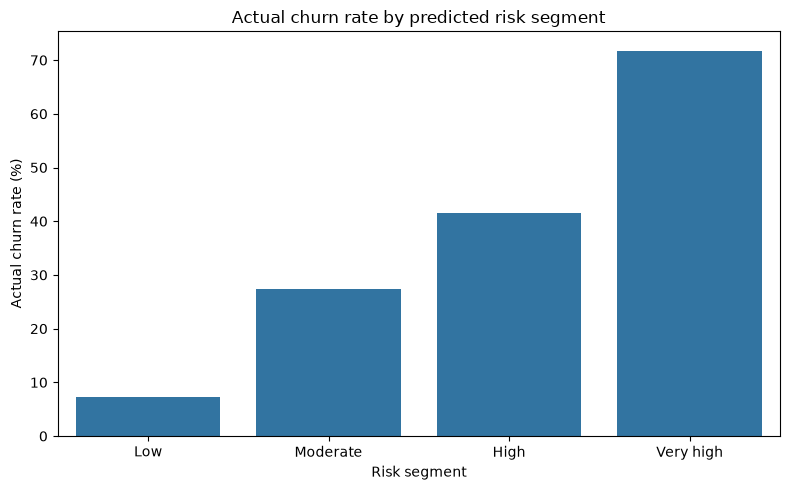

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_segment_summary,
    x="risk_segment",
    y="churn_rate"
)

plt.title("Actual churn rate by predicted risk segment")

plt.xlabel("Risk segment")
plt.ylabel("Actual churn rate (%)")

plt.tight_layout()
plt.show()

In [27]:
segment_validation = risk_segment_summary[
    [
        "risk_segment",
        "churn_rate",
        "avg_predicted_risk"
    ]
]

segment_validation.round(1)

,risk_segment,churn_rate,avg_predicted_risk
0,Low,7.3,6.3
1,Moderate,27.5,26.5
2,High,41.6,47.7
3,Very high,71.8,69.5


In [28]:
segment_validation_melted = (
    segment_validation
    .melt(
        id_vars="risk_segment",
        value_vars=[
            "churn_rate",
            "avg_predicted_risk"
        ],
        var_name="metric",
        value_name="percentage"
    )
)

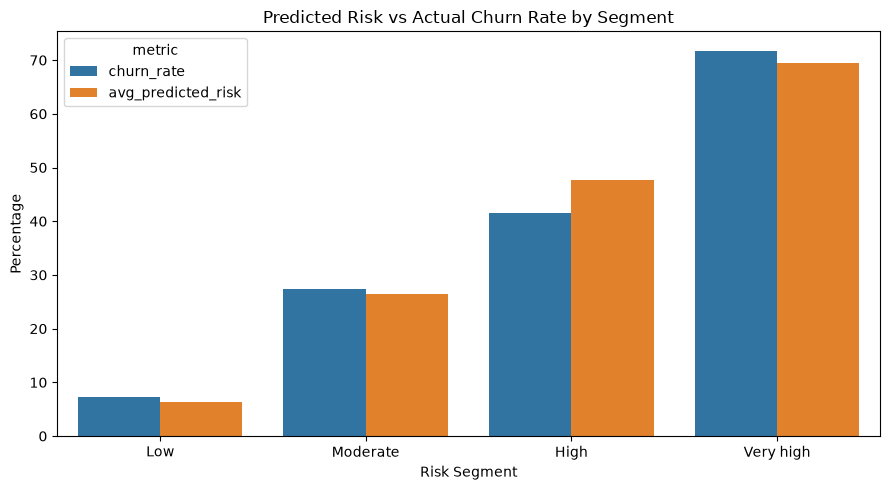

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_validation_melted,
    x="risk_segment",
    y="percentage",
    hue="metric"
)

plt.title(
    "Predicted Risk vs Actual Churn Rate by Segment"
)

plt.xlabel("Risk Segment")
plt.ylabel("Percentage")

plt.tight_layout()
plt.show()

In [30]:
retention_targets = (
    risk_results[
        risk_results[
            'churn_probabaility'
        ] >= final_threshold
    ]
    .copy()
    
)

In [31]:
retention_targets.shape

(488, 24)

In [32]:
len(retention_targets) / len(risk_results) * 100

34.63449254790631

In [33]:
retention_targets["retention_priority"] = np.where(
    retention_targets["risk_segment"] == "Very high", "High priority", "Standard priority"
)

In [34]:
retention_targets["retention_priority"].value_counts()

retention_priority
Standard priority    279
High priority        209
Name: count, dtype: int64

In [35]:
retention_targets = (
    retention_targets
    .sort_values(
        "churn_probabaility",
        ascending=False
    )
)

In [36]:
retention_targets[
    [
        "customer_id",
        "churn_probabaility",
        "risk_segment",
        "retention_priority",
        "tenure",
        "contract",
        "internet_service",
        "payment_method",
        "tech_support",
        "online_security",
        "monthly_charges"
    ]
].head(20)

,customer_id,churn_probabaility,risk_segment,retention_priority,tenure,contract,internet_service,payment_method,tech_support,online_security,monthly_charges
1090,5178-LMXOP,0.853777,Very high,High priority,1,Month-to-month,Fiber optic,Electronic check,No,No,95.10
1175,6861-XWTWQ,0.832050,Very high,High priority,7,Month-to-month,Fiber optic,Electronic check,No,No,99.25
1221,0295-PPHDO,0.828683,Very high,High priority,1,Month-to-month,Fiber optic,Electronic check,No,No,95.45
889,2545-EBUPK,0.823756,Very high,High priority,2,Month-to-month,Fiber optic,Electronic check,No,No,84.05
1355,6630-UJZMY,0.823008,Very high,High priority,4,Month-to-month,Fiber optic,Electronic check,No,No,83.25
1109,1069-XAIEM,0.818603,Very high,High priority,1,Month-to-month,Fiber optic,Electronic check,No,No,85.05
995,8161-QYMTT,0.817088,Very high,High priority,7,Month-to-month,Fiber optic,Electronic check,No,No,94.10
647,6023-YEBUP,0.810623,Very high,High priority,3,Month-to-month,Fiber optic,Electronic check,No,No,100.95
510,4750-ZRXIU,0.809395,Very high,High priority,4,Month-to-month,Fiber optic,Electronic check,No,No,84.60
1164,8884-ADFVN,0.808556,Very high,High priority,7,Month-to-month,Fiber optic,Electronic check,No,No,101.95


### Risk Segmentation Results

Customers were divided into four churn-risk segments based on the predicted
probabilities generated by the final Logistic Regression model:

- **Low risk:** predicted churn probability below 0.20
- **Moderate risk:** predicted churn probability from 0.20 to below 0.35
- **High risk:** predicted churn probability from 0.35 to below 0.60
- **Very High risk:** predicted churn probability of 0.60 or greater

The segmentation is aligned with the selected operating threshold of 0.35.
Customers in the High and Very High risk groups therefore form the proposed
retention target population.

Observed churn rates increase substantially across the risk segments,
indicating that the model successfully concentrates actual churners in the
higher-risk groups. The Low-risk segment shows the lowest observed churn,
while the Very High-risk segment contains the highest concentration of
customers who subsequently churn.

The average predicted churn probability also increases consistently across
the four segments, providing further evidence that the segmentation produces
a meaningful ranking of customer risk.

The Very High-risk segment is assigned the highest retention priority,
while customers in the High-risk segment form the broader standard
retention population. Low- and Moderate-risk customers are not prioritized
for intensive retention intervention under the current operating strategy.

This segmentation framework converts individual model probabilities into
an operational decision structure that can support differentiated retention
actions, campaign prioritization, and customer-level targeting.

In [37]:
#calculating summary profiles across the full risk segments
numerical_profile = (
    risk_results
    .groupby("risk_segment", observed=True)[
    [
        "tenure",
        "monthly_charges",
        "total_charges"
    ]
]
.mean()
.round(1)
)

numerical_profile

,tenure,monthly_charges,total_charges
risk_segment,,,
Low,45.8,54.9,2869.2
Moderate,24.7,64.9,2090.2
High,19.3,74.1,1664.7
Very high,8.3,81.6,735.0


In [38]:
contract_profile = (
    pd.crosstab(
        risk_results["risk_segment"],
        risk_results["contract"],
        normalize='index'
    )
    .mul(100)
    .round(1)
)

contract_profile

contract,Month-to-month,One year,Two year
risk_segment,,,
Low,19.9,33.5,46.6
Moderate,75.0,24.0,1.0
High,96.1,3.9,0.0
Very high,100.0,0.0,0.0


In [39]:
payment_profile = (
    pd.crosstab(
        risk_results["risk_segment"],
        risk_results["payment_method"],
        normalize="index"
    )
    .mul(100)
    .round(1)
)

payment_profile

payment_method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
risk_segment,,,,
Low,29.4,29.7,12.7,28.2
Moderate,16.7,19.6,36.3,27.5
High,15.1,15.1,51.6,18.3
Very high,6.2,6.7,78.9,8.1


In [40]:
tech_support_profile = (
    pd.crosstab(
        risk_results["risk_segment"],
        risk_results["tech_support"],
        normalize="index"
    )
    .mul(100)
    .round(1)
)

tech_support_profile

tech_support,No,No internet service,Yes
risk_segment,,,
Low,22.9,39.1,38.1
Moderate,53.9,15.7,30.4
High,81.0,0.0,19.0
Very high,96.7,0.0,3.3


In [41]:
security_profile = (
    pd.crosstab(
        risk_results["risk_segment"],
        risk_results["online_security"],
        normalize="index"
    )
    .mul(100)
    .round(1)
)

security_profile

online_security,No,No internet service,Yes
risk_segment,,,
Low,21.9,39.1,39.1
Moderate,53.9,15.7,30.4
High,82.4,0.0,17.6
Very high,97.6,0.0,2.4


### High-Risk Customer Profile

Customer profiling reveals a clear progression in customer characteristics
as predicted churn risk increases.

Very High-risk customers have substantially shorter tenure, averaging
approximately **8 months**, compared with nearly **46 months** among
Low-risk customers. At the same time, average monthly charges increase
from approximately **$55** in the Low-risk segment to more than **$81**
in the Very High-risk segment.

Contract structure shows one of the strongest differences across risk
groups. Only around **20%** of Low-risk customers are on month-to-month
contracts, compared with **96%** of High-risk customers and **100%** of
Very High-risk customers.

Payment method also differs substantially. Electronic check usage rises
from approximately **13%** among Low-risk customers to nearly **79%**
among Very High-risk customers, while automatic payment methods become
less common as churn risk increases.

Service-support characteristics show similarly strong patterns. Nearly
**97%** of Very High-risk customers do not have technical support, and
approximately **98%** do not have online security. In contrast, these
services are substantially more common among lower-risk customers.

Overall, the Very High-risk customer profile is characterized by:

- short customer tenure;
- month-to-month contracts;
- relatively high monthly charges;
- electronic-check payment;
- absence of technical support;
- absence of online security.

These characteristics should be interpreted as predictive risk indicators
rather than causal drivers of churn. However, they provide a practical
basis for designing targeted retention interventions and prioritizing
customer outreach.

## 2. Retention strategy by risk segment

The risk-segmentation analysis is translated into a differentiated
retention framework.

Rather than applying the same intervention to every customer, retention
actions are aligned with predicted churn risk and the customer
characteristics most strongly concentrated within each segment.

The proposed strategy prioritizes higher-risk customers while reserving
lower-cost, lower-intensity interventions for customers with moderate
risk. The recommendations are designed as testable business actions rather
than causal conclusions from the predictive model.

### Segment Objectives

| Risk Segment | Objective |
|---|---|
| Low | Maintain customer satisfaction with low-cost engagement and avoid unnecessary retention spend |
| Moderate | Address emerging risk signals before customers enter the active retention population |
| High | Deliver targeted interventions designed to reduce near-term churn risk |
| Very High | Prioritize immediate outreach and the strongest economically justified retention actions |

#### Low Risk

Low-risk customers should generally remain outside intensive retention
campaigns. Their lower observed churn rate suggests that aggressive
discounting would likely create unnecessary retention cost.

Recommended actions include:

- standard customer-service and loyalty communications;
- low-cost engagement and product education;
- monitoring for material changes in churn probability;
- avoiding broad retention discounts unless additional risk signals emerge.

#### Moderate Risk

Moderate-risk customers are not included in the primary retention target
population, but they represent an important prevention segment.

Recommended actions include:

- proactive onboarding and product-usage communications;
- service-quality check-ins for relatively new customers;
- promotion of automatic payment options;
- targeted education about technical-support and online-security services;
- monitoring for movement into the High-risk segment.

The objective is to reduce emerging churn risk using relatively low-cost
interventions before more intensive retention activity becomes necessary.

#### High Risk

High-risk customers form the core retention target population.

The segment is strongly associated with month-to-month contracts, shorter
tenure, electronic-check payment, and lower adoption of support and
security services.

Recommended interventions include:

- targeted incentives for migration from month-to-month to longer-term
  contracts;
- incentives to switch from electronic check to automatic payment;
- proactive service-quality outreach;
- introductory or discounted technical-support and online-security bundles;
- personalized retention communications based on the customer's current
  service configuration.

Retention offers should be tested against a control group to determine
whether they produce incremental reductions in churn.

#### Very High Risk

Very High-risk customers should receive the highest retention priority.

This segment is characterized by very short tenure, universal
month-to-month contracting, high use of electronic check, and very low
adoption of technical support and online security.

Recommended actions include:

- rapid proactive outreach through a dedicated retention channel;
- personalized contract-migration incentives;
- short-term fee reductions or loyalty credits where economically justified;
- free or discounted trials of technical-support and security services;
- service-quality reviews for high-charge fiber customers;
- tailored onboarding or account-management support for recently acquired
  customers.

Because these interventions may be more expensive, they should be reserved
for customers with sufficiently high predicted risk and expected customer
value.

### Retention Strategy Matrix

| Segment | Primary Objective | Recommended Intervention Level | Example Actions |
|---|---|---|---|
| Low | Maintain | Low | Standard engagement, loyalty communication, monitoring |
| Moderate | Prevent escalation | Low–Moderate | Onboarding, payment-method education, service check-ins |
| High | Reduce churn | Moderate | Contract incentives, autopay migration, support/security offers |
| Very High | Immediate retention | High | Personalized outreach, stronger incentives, service review, bundled support |

In [42]:
def assign_retention_action(row):
    if row["risk_segment"] == "Very high":
        return "Priority outreach + personalized retention offer"
    elif row["risk_segment"] == "High":
        return "Targeted retention campaign"
    elif row["risk_segment"] == "Moderate":
        return "Preventative engagement"
    else:
        return "Standard engagement"

In [43]:
risk_results["recommended_action"] = (
    risk_results.apply(
        assign_retention_action,
        axis=1
    )
)

In [44]:
risk_results[
    [
        "customer_id",
        "churn_probabaility",
        "risk_segment",
        "recommended_action"
    ]
].head(20)

,customer_id,churn_probabaility,risk_segment,recommended_action
0,4376-KFVRS,0.047876,Low,Standard engagement
1,2754-SDJRD,0.682909,Very high,Priority outreach + personalized retention offer
2,9917-KWRBE,0.050820,Low,Standard engagement
3,0365-GXEZS,0.420815,High,Targeted retention campaign
4,9385-NXKDA,0.022827,Low,Standard engagement
5,4686-UXDML,0.603154,Very high,Priority outreach + personalized retention offer
6,2227-JRSJX,0.454554,High,Targeted retention campaign
7,4830-FAXFM,0.133062,Low,Standard engagement
8,1830-IPXVJ,0.002645,Low,Standard engagement
9,4690-LLKUA,0.393080,High,Targeted retention campaign


In [45]:
#risk_pattern_specific actions
def assign_specific_action(row):
    actions = []

    if row["contract"] == "Month-to-month":
        actions.append(
            "Offer contract migration incentive"
        )

    if row["payment_method"] == "Electronic check":
        actions.append(
            "Promote automatic payment"
        )

    if row["online_security"] == "No":
        actions.append(
            "Offer online security bundle"
        )

    if row["tenure"] <= 12:
        actions.append(
            "Provide proactive onboarding outreach"
        )

    return "; ".join(actions)

In [46]:
risk_results["specific_actions"] = (
    risk_results.apply(
        assign_specific_action,
        axis=1
    )
)

In [47]:
risk_results[
    risk_results["risk_segment"].isin(
        ["High", "Very high"]
    )
][
    [
        "customer_id",
        "churn_probabaility",
        "risk_segment",
        "specific_actions"
    ]
].sort_values(
    "churn_probabaility",
    ascending=False
).head(20)

,customer_id,churn_probabaility,risk_segment,specific_actions
1090,5178-LMXOP,0.853777,Very high,Offer contract migration incentive; Promote au...
1175,6861-XWTWQ,0.832050,Very high,Offer contract migration incentive; Promote au...
1221,0295-PPHDO,0.828683,Very high,Offer contract migration incentive; Promote au...
889,2545-EBUPK,0.823756,Very high,Offer contract migration incentive; Promote au...
1355,6630-UJZMY,0.823008,Very high,Offer contract migration incentive; Promote au...
1109,1069-XAIEM,0.818603,Very high,Offer contract migration incentive; Promote au...
995,8161-QYMTT,0.817088,Very high,Offer contract migration incentive; Promote au...
647,6023-YEBUP,0.810623,Very high,Offer contract migration incentive; Promote au...
510,4750-ZRXIU,0.809395,Very high,Offer contract migration incentive; Promote au...
1164,8884-ADFVN,0.808556,Very high,Offer contract migration incentive; Promote au...


### Interpretation Note

The recommended interventions are derived from customer characteristics
associated with elevated churn risk in the predictive analysis.

These relationships should not be interpreted as evidence that changing
a specific characteristic will necessarily cause churn to decline.

The proposed actions should therefore be tested using controlled
experiments, such as randomized retention campaigns or A/B tests, to
measure incremental retention impact and economic value.

## 3. Campaign economics and ROI

The retention strategy is evaluated using a simple scenario-based economic
model.

The objective is to estimate whether targeted retention activity could
generate positive business value under different assumptions about
intervention cost, retention success rate, and customer value.

Because the dataset does not contain actual campaign costs or customer
lifetime value, the analysis uses transparent business assumptions rather
than presenting estimated ROI as an observed result.

In [48]:
n_targets = len(retention_targets)

n_targets

488

In [49]:
target_rate = (
    n_targets / len(risk_results)
)

target_rate

0.34634492547906315

In [50]:
targeted_actual_churners = (
    retention_targets["actual_churn"].sum()
)

targeted_actual_churners

np.int64(266)

In [51]:
target_precision = (
    targeted_actual_churners / n_targets
)

target_precision

np.float64(0.5450819672131147)

In [52]:
#defining business assuptions
campaign_cost_per_customer = 25
retention_success_rate = 0.20
customer_value = 500

In [53]:
#calculating total campaign cost
total_campaign_cost = (
    n_targets * campaign_cost_per_customer
)

total_campaign_cost

12200

In [54]:
#estimating retained customers
retained_customers = (
    targeted_actual_churners * retention_success_rate
)

retained_customers

np.float64(53.2)

In [55]:
#estimating preserved value
preserved_value = (
    retained_customers * customer_value
)

preserved_value

np.float64(26600.0)

In [56]:
#calculating net benefit
net_benefit = (
    preserved_value - total_campaign_cost
)

net_benefit

np.float64(14400.0)

In [57]:
#calculating ROI
roi = (
    net_benefit / total_campaign_cost
)

roi

np.float64(1.180327868852459)

In [58]:
roi_percentage = roi * 100

roi_percentage

np.float64(118.0327868852459)

In [59]:
roi_summary = pd.DataFrame({
    "Metric": [
        "Customers targeted",
        "Actual churners targeted",
        "Campaign cost per customer",
        "Retention success rate",
        "Value per retained customer",
        "Total campaign cost",
        "Estimated customers retained",
        "Estimated preserved value",
        "Estimated net benefit",
        "Estimated ROI"
    ],
    "Value": [
        n_targets,
        targeted_actual_churners,
        campaign_cost_per_customer,
        retention_success_rate,
        customer_value,
        total_campaign_cost,
        retained_customers,
        preserved_value,
        net_benefit,
        roi
    ]
})

roi_summary

,Metric,Value
0,Customers targeted,488.000000
1,Actual churners targeted,266.000000
2,Campaign cost per customer,25.000000
3,Retention success rate,0.200000
4,Value per retained customer,500.000000
5,Total campaign cost,12200.000000
6,Estimated customers retained,53.200000
7,Estimated preserved value,26600.000000
8,Estimated net benefit,14400.000000
9,Estimated ROI,1.180328


In [60]:
scenarios = pd.DataFrame({
    "Scenario": [
        "Conservative",
        "Base",
        "Optimistic"
    ],

    "Cost per Target": [
        30,
        25,
        20
    ],

    "Retention Success Rate": [
        0.10,
        0.20,
        0.30
    ],

    "Value per Retained Customer": [
        400,
        500,
        600
    ]
})

In [61]:
scenarios["Campaign Cost"] = (
    n_targets
    * scenarios["Cost per Target"]
)

scenarios["Estimated Customers Retained"] = (
    targeted_actual_churners
    * scenarios["Retention Success Rate"]
)

scenarios["Preserved Value"] = (
    scenarios["Estimated Customers Retained"]
    * scenarios["Value per Retained Customer"]
)

scenarios["Net Benefit"] = (
    scenarios["Preserved Value"]
    - scenarios["Campaign Cost"]
)

scenarios["ROI"] = (
    scenarios["Net Benefit"]
    / scenarios["Campaign Cost"]
)

scenarios.round(2)

,Scenario,Cost per Target,Retention Success Rate,Value per Retained Customer,Campaign Cost,Estimated Customers Retained,Preserved Value,Net Benefit,ROI
0,Conservative,30,0.1,400,14640,26.6,10640.0,-4000.0,-0.27
1,Base,25,0.2,500,12200,53.2,26600.0,14400.0,1.18
2,Optimistic,20,0.3,600,9760,79.8,47880.0,38120.0,3.91


In [62]:
scenarios["ROI (%)"] = (
    scenarios["ROI"] * 100
)

scenarios.round(1)

,Scenario,Cost per Target,Retention Success Rate,Value per Retained Customer,Campaign Cost,Estimated Customers Retained,Preserved Value,Net Benefit,ROI,ROI (%)
0,Conservative,30,0.1,400,14640,26.6,10640.0,-4000.0,-0.3,-27.3
1,Base,25,0.2,500,12200,53.2,26600.0,14400.0,1.2,118.0
2,Optimistic,20,0.3,600,9760,79.8,47880.0,38120.0,3.9,390.6


In [63]:
#calculating break-even retention rate
break_even_retention_rate = (
    total_campaign_cost / (targeted_actual_churners * customer_value)
)

break_even_retention_rate

np.float64(0.09172932330827067)

In [64]:
#minimum intervention success rate needed to avoid losing money
break_even_retention_rate * 100

np.float64(9.172932330827068)

### Scenario Framework

Because actual intervention costs and customer lifetime value are not
available in the source dataset, campaign economics are evaluated using
illustrative scenarios.

| Scenario | Cost per Target | Retention Success Rate | Value per Retained Customer |
|---|---:|---:|---:|
| Conservative | $30 | 10% | $400 |
| Base | $25 | 20% | $500 |
| Optimistic | $20 | 30% | $600 |

These assumptions are used to estimate campaign cost, customers retained,
preserved value, net benefit, and ROI.

In [65]:
scenarios["Break-even Retention Rate"] = (
    scenarios["Campaign Cost"]
    / (
        targeted_actual_churners
        * scenarios["Value per Retained Customer"]
    )
)

scenarios["Break-even Retention Rate (%)"] = (
    scenarios["Break-even Retention Rate"] * 100
)

scenarios[
    [
        "Scenario",
        "Retention Success Rate",
        "Break-even Retention Rate (%)",
        "ROI (%)"
    ]
].round(1)

,Scenario,Retention Success Rate,Break-even Retention Rate (%),ROI (%)
0,Conservative,0.1,13.8,-27.3
1,Base,0.2,9.2,118.0
2,Optimistic,0.3,6.1,390.6


### Campaign Economics Results

The scenario analysis demonstrates that the financial viability of the
retention campaign depends materially on intervention cost, retention
effectiveness, and the value of successfully retained customers.

Under the **Conservative scenario**, the campaign generates an estimated
net loss of **$4,000**, corresponding to an ROI of approximately **-27%**.
This indicates that targeted retention is not automatically profitable if
interventions are relatively expensive and produce limited incremental
retention.

Under the **Base scenario**, the campaign is estimated to cost **$12,200**
and retain approximately **53 customers** who would otherwise churn. The
resulting preserved customer value is approximately **$26,600**, producing
an estimated net benefit of **$14,400** and ROI of approximately **118%**.

Under the **Optimistic scenario**, lower intervention cost, stronger
retention effectiveness, and higher customer value produce an estimated
net benefit of **$38,120** and ROI of approximately **391%**.

These results demonstrate that model-based targeting can support positive
economic returns, but profitability depends on the effectiveness and cost
of the actual retention intervention. The Base scenario provides the most
useful reference case, while the Conservative and Optimistic scenarios
illustrate downside and upside sensitivity.

Because the dataset does not contain observed retention-campaign outcomes,
the results should be interpreted as scenario-based decision support rather
than forecasts of realized financial impact.

## 4. Final business recommendations

The analysis indicates that churn risk is concentrated among a relatively well-defined customer profile: customers with shorter tenure, month-to-month contracts, higher monthly charges, electronic-check payment, and limited adoption of technical support and online security services.

Based on the combined EDA, predictive modeling, risk segmentation, and campaign economics, the following actions are recommended:

### 1. Prioritize early-tenure, month-to-month customers

Very High-risk customers have substantially shorter tenure and are universally on month-to-month contracts.

Retention activity should therefore focus especially on customers in the early stages of their relationship with the company. Proactive onboarding, service check-ins, and targeted contract-migration offers should be tested before these customers become established churn risks.

### 2. Test incentives for longer-term contracts

Contract structure was one of the most consistent churn indicators across exploratory analysis, Logistic Regression, Decision Tree, and Random Forest models.

High- and Very High-risk month-to-month customers should be considered for targeted incentives to move to one- or two-year contracts, such as temporary discounts, loyalty credits, or bundled benefits.

Because the analysis is predictive rather than causal, these offers should be evaluated through controlled experiments to determine whether contract migration produces incremental retention.

### 3. Target electronic-check customers with automatic-payment offers

Electronic-check usage increases sharply with predicted churn risk and is heavily concentrated among Very High-risk customers.

The company should test incentives for customers to migrate toward automatic bank transfer or credit-card payment. Potential interventions could include small account credits, simplified enrollment, or bundled loyalty benefits.

### 4. Strengthen support and security engagement

Customers without technical support and online security are disproportionately represented in the High- and Very High-risk segments.

Targeted customers could receive free trials, discounted bundles, or proactive education around these services. For recently acquired customers, service-support outreach may also help identify unresolved technical or onboarding issues.

### 5. Use differentiated retention intensity

The final model should not be used to apply the same retention treatment to every customer.

A tiered approach is recommended:

| Risk Segment | Recommended Strategy                                                             |
| ------------ | -------------------------------------------------------------------------------- |
| Low          | Standard engagement and monitoring                                               |
| Moderate     | Preventive, low-cost engagement                                                  |
| High         | Targeted retention offers                                                        |
| Very High    | Immediate prioritized outreach and stronger economically justified interventions |

Using the selected Logistic Regression threshold of **0.35**, approximately **34.6% of customers** are included in the active retention target population while approximately **71% of actual churners** are identified.

### 6. Measure incremental retention impact

Predictive accuracy does not establish that a recommended intervention will prevent churn.

Retention programs should therefore be implemented using randomized control groups or A/B tests. Key measures should include:

* incremental churn reduction;
* retention conversion rate;
* cost per retained customer;
* preserved customer value;
* campaign net benefit;
* return on investment.

The scenario analysis suggests that targeted retention can generate positive economic value under reasonable assumptions, but the Conservative scenario also demonstrates that poorly performing or expensive interventions can produce negative returns.

### Final Recommendation

The company should implement a targeted retention pilot focused on High- and Very High-risk customers, particularly recently acquired month-to-month customers exhibiting multiple elevated-risk characteristics.

The Logistic Regression model should be used to prioritize customers, while intervention effectiveness should be measured experimentally. The initial pilot should focus on contract migration, payment-method conversion, proactive customer support, and targeted service bundles.

The objective should not simply be to maximize model accuracy, but to maximize the economic value of retained customers while controlling unnecessary retention spend.


## 5. Project Conclusion

This project developed an end-to-end customer churn and retention framework using the Telco Customer Churn dataset.

A tuned Logistic Regression model was selected as the final model because it provided strong predictive discrimination, competitive precision-recall performance, and substantially greater interpretability than the more complex alternatives. Using an operating threshold of **0.35**, the final model achieved **71.1% recall**, **54.5% precision**, an **F1-score of 0.617**, and an **ROC-AUC of 0.841** on the held-out test set while targeting approximately **34.6% of customers**.

Risk segmentation showed a clear increase in observed churn across Low, Moderate, High, and Very High-risk groups. The highest-risk customers were characterized by short tenure, month-to-month contracts, relatively high monthly charges, electronic-check payment, and low adoption of technical support and online security.

These findings were translated into a differentiated retention strategy focused on early-tenure engagement, contract migration, automatic-payment adoption, proactive support, and targeted service bundles.

Scenario-based campaign economics indicate that model-driven targeting can generate positive value under reasonable assumptions, while also showing that retention activity is not automatically profitable if intervention costs are high or retention effectiveness is weak.

Overall, the analysis demonstrates how predictive modeling can be combined with customer segmentation and business economics to move from churn prediction toward an actionable, testable retention strategy.


In [66]:
risk_results.columns.tolist()

['customer_id',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'actual_churn',
 'churn_probabaility',
 'predicted_churn',
 'risk_segment',
 'recommended_action',
 'specific_actions']

In [67]:
risk_results["retention_priority"] = np.select(
    [
        risk_results["risk_segment"] == "Very high",
        risk_results["risk_segment"] == "High"
    ],
    [
        "High priority",
        "Standard priority"
    ],
    default="Not targeted"
)

In [68]:
risk_results["retention_target"] = np.where(
    risk_results["churn_probabaility"] >= final_threshold,
    "Target",
    "Not target"
)

In [69]:
risk_results["tenure_group"] = pd.cut(
    risk_results["tenure"],
    bins=[0,6,12,24,48,72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "45-72 months"
    ],
    include_lowest=True
)

In [70]:
risk_results["churn_status"] = np.where(
    risk_results["actual_churn"] == 1,
    "Churned",
    "Stayed"
)

In [71]:
risk_results["predicted_churn"] = np.where(
    risk_results["predicted_churn"] == 1,
    "Predicted churn",
    "Predicted stay"
)

In [72]:
overview_data["actual_churn"] = (
    overview_data["churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

In [73]:
overview_data["actual_churn"] = overview_data["churn"]

overview_data["churn_status"] = np.where(
    overview_data["actual_churn"] == 1,
    "Churned",
    "Stayed"
)

In [74]:
overview_data["tenure_group"] = pd.cut(
    overview_data["tenure"],
    bins=[0,6,12,24,48,72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "45-72 months"
    ],
    include_lowest=True
)

In [75]:
overview_data["actual_churn"] = (
    overview_data["churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

In [76]:
overview_data["churn_status"] = np.where(
    overview_data["actual_churn"] == 1,
    "Churned",
    "Stayed"
)

In [77]:
risk_results.to_csv(
    "../../1_data/2_processed/dashboard_customer_data.csv",
    index=False
)

In [78]:
overview_data.to_csv(
    "../../1_data/2_processed/dashboard_overview.csv",
    index=False
)

In [79]:
scenarios.to_csv(
    "../../1_data/2_processed/retention_roi_scenarios.csv",
    index=False
)